# Filters


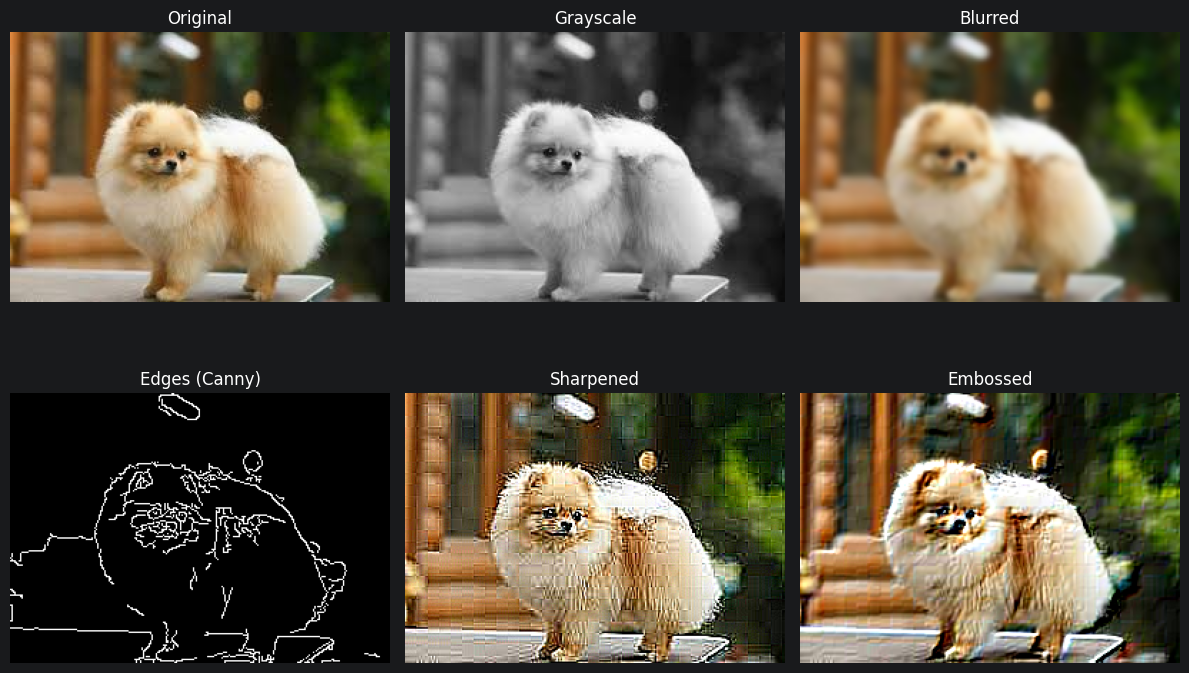

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load an image (replace 'your_image.jpg' with the image file path)
image_path = 'content/About_The_Dog.jpg'
image = cv2.imread(image_path)

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Define common image filters
filters = [
    ('Original', image), ('Grayscale', gray_image), ('Blurred', cv2.GaussianBlur(image, (9, 9), 0)),
    ('Edges (Canny)', cv2.Canny(image, 100, 200)),
    ('Sharpened', cv2.filter2D(image, -1, np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]]))),
    ('Embossed', cv2.filter2D(image, -1, np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])))
]

# Display images with filters
plt.figure(figsize=(12, 8))

for i, (filter_name, filtered_image) in enumerate(filters):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(filtered_image, cv2.COLOR_BGR2RGB))

    # Convert BGR to RGB for Matplotlib
    plt.title(filter_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Convolution to pooling

In [2]:
import torch
import torch.nn.functional as F  # Functions for deep learning operations

pooling_window_size = 2
pooling_stride = 2

# Read the image using OpenCV
image = cv2.imread('landscape.jpg')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Convert the grayscale image to a PyTorch tensor
image_tensor = torch.tensor(gray_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Apply max pooling using PyTorch
max_pooled = F.max_pool2d(image_tensor, pooling_window_size, stride=pooling_stride)

# torchvision.transforms

In [3]:
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
# Load an image
image = Image.open('landscape.jpg')

In [5]:
# Define a sequence of transformations
transform = transforms.Compose(
        [
            transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(), transforms.ToTensor(),
            transforms.RandomVerticalFlip(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]
)

In [6]:
# Apply the transformations to the image
transformed_image = transform(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


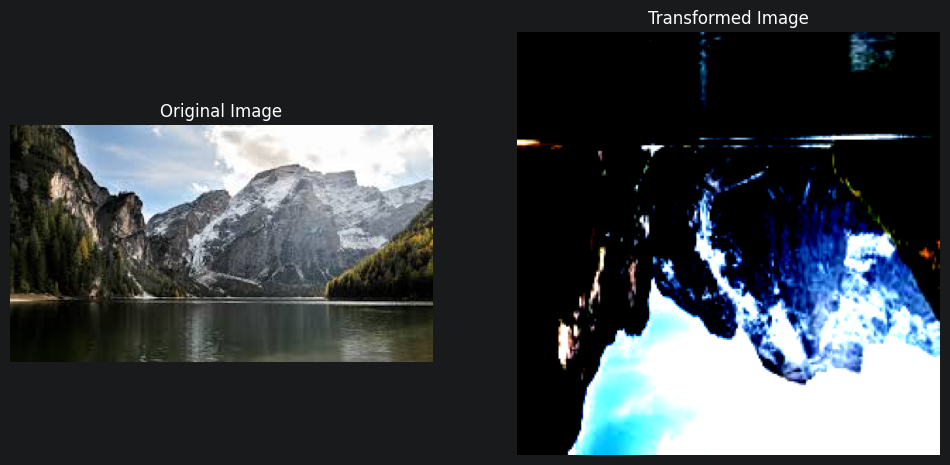

In [7]:
# Display the original and transformed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original Image
axes[0].set_title('Original Image')
axes[0].imshow(image)
axes[0].axis('off')

# Transformed Image
axes[1].set_title('Transformed Image')

# Since the transformed image is a tensor, we need to convert it back to a NumPy array for display
axes[1].imshow(transformed_image.permute(1, 2, 0))  # Transpose the dimensions
axes[1].axis('off')
plt.show()

# Combining components to create a complete CNN network

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [9]:
# Define transformations to preprocess the data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load the Fashion MNIST dataset
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

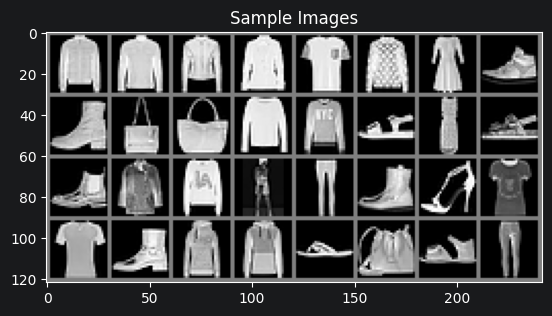

Labels: Coat, Coat, Coat, Coat


In [10]:
#visualize datasets
# Define class labels
class_labels = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]


# Function to show images
def imshow(img, title):
    img = img / 2 + 0.5  # Unnormalize the image
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.show()


# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images), 'Sample Images')

# Print labels
print('Labels:', ', '.join(class_labels[labels[j]] for j in range(4)))

In [11]:
# Define the CNN architecture using nn.Sequential
model = nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1),  # First Convolutional Layer
        nn.ReLU(),  # Activation function (ReLU)
        nn.MaxPool2d(2, 2),  # First Max-Pooling Layer
        nn.Conv2d(32, 64, 3, padding=1),  # Second Convolutional Layer
        nn.ReLU(),  # Activation function (ReLU)
        nn.MaxPool2d(2, 2),  # Second Max-Pooling Layer
        nn.Flatten(),  # Flatten layer
        nn.Linear(64 * 7 * 7, 128),  # Fully connected layer 1
        nn.ReLU(),  # Activation function (ReLU)
        nn.Linear(128, 10)  # Fully connected layer 2 (output)
)

In [12]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [13]:
accuracy_values = []
loss_values = []

# Training loop
for epoch in range(5):  # You can adjust the number of epochs
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}')

        running_loss = 0.0

    # Calculate accuracy for the epoch and append to the accuracy list
    accuracy = 100 * correct / total
    accuracy_values.append(accuracy)
    loss_values.append(running_loss / len(trainloader))  # Average loss per batch

print('Finished Training')

[Epoch 1, Batch 100] Loss: 0.020
[Epoch 1, Batch 200] Loss: 0.011
[Epoch 1, Batch 300] Loss: 0.006
[Epoch 1, Batch 400] Loss: 0.009
[Epoch 1, Batch 500] Loss: 0.008
[Epoch 1, Batch 600] Loss: 0.007
[Epoch 1, Batch 700] Loss: 0.005
[Epoch 1, Batch 800] Loss: 0.009
[Epoch 1, Batch 900] Loss: 0.006
[Epoch 1, Batch 1000] Loss: 0.005
[Epoch 1, Batch 1100] Loss: 0.009
[Epoch 1, Batch 1200] Loss: 0.003
[Epoch 1, Batch 1300] Loss: 0.005
[Epoch 1, Batch 1400] Loss: 0.005
[Epoch 1, Batch 1500] Loss: 0.004
[Epoch 1, Batch 1600] Loss: 0.005
[Epoch 1, Batch 1700] Loss: 0.005
[Epoch 1, Batch 1800] Loss: 0.004
[Epoch 2, Batch 100] Loss: 0.008
[Epoch 2, Batch 200] Loss: 0.004
[Epoch 2, Batch 300] Loss: 0.006
[Epoch 2, Batch 400] Loss: 0.004
[Epoch 2, Batch 500] Loss: 0.006
[Epoch 2, Batch 600] Loss: 0.004
[Epoch 2, Batch 700] Loss: 0.006
[Epoch 2, Batch 800] Loss: 0.005
[Epoch 2, Batch 900] Loss: 0.005
[Epoch 2, Batch 1000] Loss: 0.004
[Epoch 2, Batch 1100] Loss: 0.001
[Epoch 2, Batch 1200] Loss: 0.00

In [14]:
# Define the CNN architecture using nn.Sequential
model = nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1),  # First Convolutional Layer
        nn.ReLU(),  # Activation function (ReLU)
        nn.MaxPool2d(2, 2),  # First Max-Pooling Layer
        nn.Conv2d(32, 64, 3, padding=1),  # Second Convolutional Layer
        nn.ReLU(),  # Activation function (ReLU)
        nn.MaxPool2d(2, 2),  # Second Max-Pooling Layer
        nn.Flatten(),  # Flatten layer
        nn.Linear(64 * 7 * 7, 128),  # Fully connected layer 1
        nn.ReLU(),  # Activation function (ReLU)
        nn.Linear(128, 10)  # Fully connected layer 2 (output)
)

# Usage of CNN in enterprises

In [15]:
import os
from torch.utils.data import Dataset


# Define a custom dataset class
class Caltech101Dataset(Dataset):
    # Constructor (__init__ method)
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths, self.labels = self.load_dataset()

    # Helper function to load the dataset
    def load_dataset(self):
        image_paths = []
        labels = []
        classes = sorted(os.listdir(self.root_dir))

        for i, class_name in enumerate(classes):
            class_dir = os.path.join(self.root_dir, class_name)

            if os.path.isdir(class_dir):
                image_names = os.listdir(class_dir)

                for image_name in image_names:
                    image_path = os.path.join(class_dir, image_name)
                    image_paths.append(image_path)
                    labels.append(i)

        return image_paths, labels

    # Implementation of the __len__ method
    def __len__(self):
        return len(self.image_paths)

    # Implementation of the __getitem__ method
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path)

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, lab

In [16]:
from torch.utils.data import DataLoader, random_split

# Load the Caltech101 dataset using the custom dataset class
transform = transforms.Compose(
        [
            transforms.Resize((32, 32)), transforms.Grayscale(), transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ]
)
dataset = Caltech101Dataset(root_dir='./caltech-101', transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False, num_workers=2)

In [17]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 128, 3)
        self.pool = nn.MaxPool2d(2, 2)

        # Calculate the expected input size for the first fully connected layer
        fc1_input_size = 128 * 2 * 2  # This should match the output size of the last conv layer
        self.fc1 = nn.Linear(fc1_input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 102)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [18]:
class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.fc1 = nn.Linear(784, 128)  # Example: Fully connected layer
        self.fc2 = nn.Linear(128, 10)  # Another fully connected layer

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Apply ReLU activation
        x = self.fc2(x)
        return x

In [19]:
model = CustomModel()  # Create an object of your custom model

# Visualizing CNN internal layers

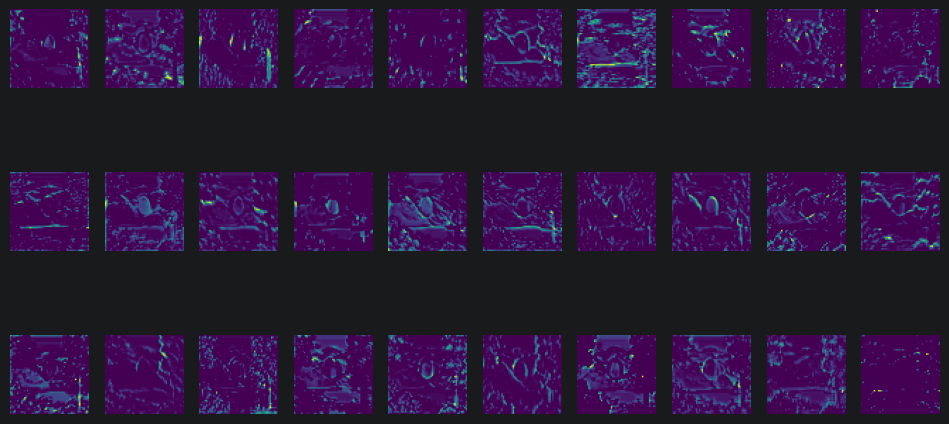

In [21]:
from torchvision import models

# Load the pre-trained VGG16 model
model = models.vgg16(pretrained=True)
model.eval()  # Set the model to evaluation mode


# Define a function to visualize intermediate layers
def visualize_layers(model, image_path, target_layer):
    # Load and preprocess the image
    preprocess = transforms.Compose(
            [
                transforms.Resize((224, 224)), transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ]
    )

    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0)  # Add batch dimension

    # Forward pass to the target layer
    activations = None

    def hook_fn(module, input, output):
        nonlocal activations
        activations = output

    model.features[target_layer].register_forward_hook(hook_fn)

    with torch.no_grad():
        model(image_tensor)

    # Visualize the feature maps
    feature_maps = activations[0].cpu().detach()
    plt.figure(figsize=(12, 6))

    for i in range(min(30, feature_maps.shape[0])):  # Display the first 30 feature maps
        plt.subplot(3, 10, i + 1)
        plt.imshow(feature_maps[i], cmap="viridis")
        plt.axis("off")

    plt.show()


# Specify the path to your image and the target layer (0-30 for VGG16)
image_path = "mhq2_g9ei_220304.jpg"  # change if needed
target_layer = 10  # You can change this to visualize different layers

# Visualize the intermediate layer outputs
visualize_layers(model, image_path, target_layer)